# 01 — Cleaning the RAS sensor data

In this notebook I check the raw CSV, fix structural problems, flag unreliable readings and save a clean file for analysis.

I keep the approach deliberately simple and explain each decision. I do not delete a whole row when only one sensor value is bad.

## 1. Load the data and form an expectation

The dataset should contain four tanks, 90 days and one reading every ten minutes. That gives:

`4 × 90 × 24 × 6 = 51,840` expected unique readings.

If the raw file has more rows, duplicates are a likely reason. I also expect timestamps to need parsing and tank labels to need standardising.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("..").resolve()

sns.set_theme(style="whitegrid")
raw_path = PROJECT_ROOT / "data" / "ras_sensors_dirty.csv"
raw = pd.read_csv(raw_path)

print("Shape:", raw.shape)
display(raw.head())
raw.info()

Shape: (51865, 8)


,timestamp,tank_id,temp_c,do_mgL,ph,ammonia_mgL,turbidity_ntu,flow_Lmin
0,2026-05-21 20:00:00,T1,29.12,7.39,6.92,0.248,3.5,421.3
1,2026-04-30 14:00:00,T4,29.38,6.32,6.76,1.373,5.5,423.0
2,2026-04-06 11:10:00,T2,28.11,6.66,6.90,0.217,3.6,419.4
3,2026-04-19 16:10:00,T4,29.47,7.21,7.18,0.207,3.4,420.8
4,2026-03-12 13:10:00,T2,28.11,6.03,6.97,0.418,7.0,422.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51865 entries, 0 to 51864
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      51865 non-null  object 
 1   tank_id        51865 non-null  object 
 2   temp_c         51577 non-null  float64
 3   do_mgL         51577 non-null  float64
 4   ph             51577 non-null  float64
 5   ammonia_mgL    51577 non-null  float64
 6   turbidity_ntu  51577 non-null  float64
 7   flow_Lmin      51577 non-null  float64
dtypes: float64(6), object(2)
memory usage: 3.2+ MB


## 2. Check the main structural problems

In [2]:
checks = pd.Series({
    "rows": len(raw),
    "expected unique rows": 4 * 90 * 24 * 6,
    "exact duplicate rows": raw.duplicated().sum(),
    "missing sensor cells": raw[[
        "temp_c", "do_mgL", "ph", "ammonia_mgL", "turbidity_ntu", "flow_Lmin"
    ]].isna().sum().sum(),
    "timestamps already sorted": pd.to_datetime(raw["timestamp"]).is_monotonic_increasing,
}, name="result")
display(checks.to_frame())
print("Tank labels before cleaning:", sorted(raw["tank_id"].unique()))

,result
rows,51865
expected unique rows,51840
exact duplicate rows,25
missing sensor cells,1728
timestamps already sorted,False


Tank labels before cleaning: ['T1', 'T2', 'T2 ', 'T3', 'T4', 'Tank3']


## 3. Parse dates, fix tank labels, remove duplicates and sort

I strip spaces, use upper case and convert labels such as `Tank3` to `T3`. I remove only exact duplicate records, then sort by tank and time.

In [3]:
df = raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

original_labels = df["tank_id"].copy()
df["tank_id"] = (
    df["tank_id"].str.strip().str.upper().str.replace(r"^TANK", "T", regex=True)
)
label_changes = int((original_labels != df["tank_id"]).sum())

duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().sort_values(["tank_id", "timestamp"]).reset_index(drop=True)

print(f"Labels fixed: {label_changes}")
print(f"Duplicates removed: {duplicate_count}")
print("Tank labels after cleaning:", df["tank_id"].unique())
print("New shape:", df.shape)

Labels fixed: 7
Duplicates removed: 25
Tank labels after cleaning: ['T1' 'T2' 'T3' 'T4']
New shape: (51840, 8)


## 4. Flag impossible values and missing data

I treat isolated DO readings below 0.5 or above 15 mg/L as unreliable for this aerated system. Negative flow is physically impossible. I replace only those values with `NaN` and keep a flag showing why.

Rows where all six signals are missing form a logger outage. I leave this block missing because filling a two-day gap would invent data.

In [4]:
signals = ["temp_c", "do_mgL", "ph", "ammonia_mgL", "turbidity_ntu", "flow_Lmin"]

df["flag_logger_outage"] = df[signals].isna().all(axis=1)
df["flag_invalid_do"] = df["do_mgL"].notna() & (
    (df["do_mgL"] < 0.5) | (df["do_mgL"] > 15)
)
df["flag_invalid_flow"] = df["flow_Lmin"].notna() & (df["flow_Lmin"] < 0)

df.loc[df["flag_invalid_do"], "do_mgL"] = np.nan
df.loc[df["flag_invalid_flow"], "flow_Lmin"] = np.nan

outage = df[df["flag_logger_outage"]]
display(outage.groupby("tank_id").agg(
    start=("timestamp", "min"), end=("timestamp", "max"), rows=("timestamp", "size")
))
print("Invalid DO rows:", df["flag_invalid_do"].sum())
print("Negative flow rows:", df["flag_invalid_flow"].sum())

,start,end,rows
tank_id,,,
T1,2026-05-05,2026-05-06 23:50:00,288


Invalid DO rows: 59
Negative flow rows: 15


## 5. Look for a stuck pH sensor

A real pH signal changes slightly over time. I flag any exact repeated run lasting at least 12 hours (72 ten-minute readings).

In [5]:
def flag_long_repeated_run(series, minimum=72):
    run_number = (series.ne(series.shift()) | series.isna()).cumsum()
    run_length = run_number.groupby(run_number).transform("size")
    return (run_length >= minimum) & series.notna()

df["flag_stuck_ph"] = df.groupby("tank_id")["ph"].transform(flag_long_repeated_run)

stuck = df[df["flag_stuck_ph"]]
display(stuck.groupby("tank_id").agg(
    start=("timestamp", "min"), end=("timestamp", "max"), rows=("timestamp", "size")
))

,start,end,rows
tank_id,,,
T3,2026-04-09 23:50:00,2026-04-12 23:50:00,433


## 6. Compare tanks to find plausible-looking sensor faults

Range checks cannot find every problem. I calculate each tank's daily difference from the other tanks. A large, persistent difference suggests a sensor issue rather than a system-wide change.

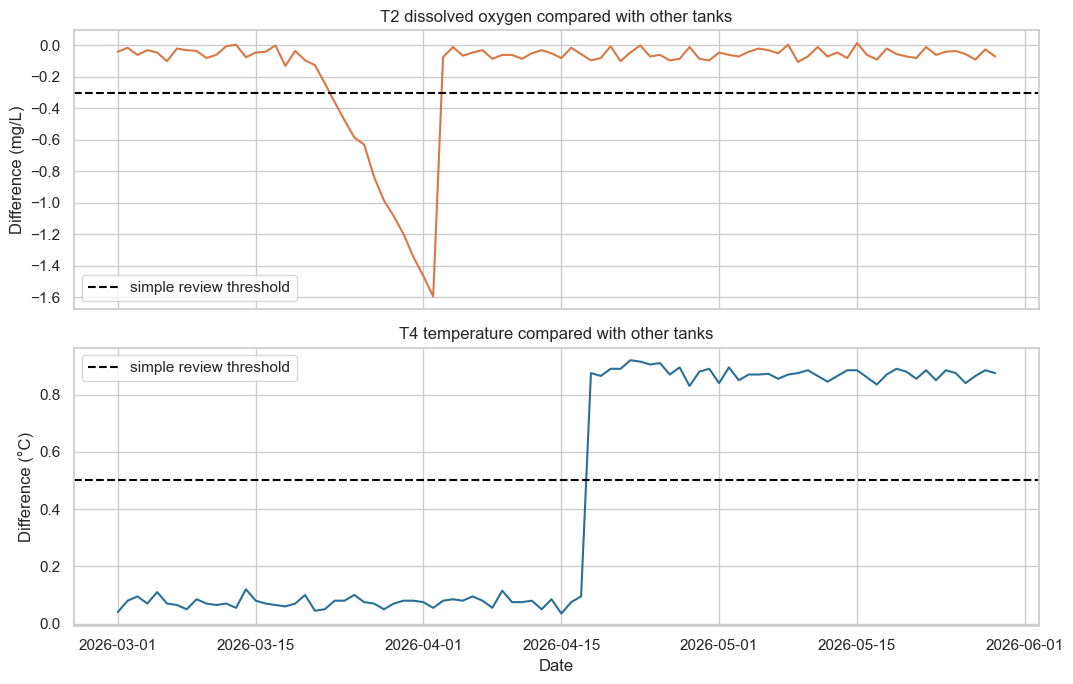

In [6]:
daily_do = df.pivot(index="timestamp", columns="tank_id", values="do_mgL").resample("D").median()
t2_do_difference = daily_do["T2"] - daily_do.drop(columns="T2").median(axis=1)
fouling_days = t2_do_difference[t2_do_difference < -0.3].index.normalize()
df["flag_do_drift"] = (
    df["tank_id"].eq("T2") & df["timestamp"].dt.normalize().isin(fouling_days)
)

daily_temp = df.pivot(index="timestamp", columns="tank_id", values="temp_c").resample("D").median()
t4_temp_difference = daily_temp["T4"] - daily_temp.drop(columns="T4").median(axis=1)
calibration_days = t4_temp_difference[t4_temp_difference > 0.5].index.normalize()
df["flag_temp_shift"] = (
    df["tank_id"].eq("T4") & df["timestamp"].dt.normalize().isin(calibration_days)
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(t2_do_difference.index, t2_do_difference, color="#d97745")
axes[0].axhline(-0.3, color="black", linestyle="--", label="simple review threshold")
axes[0].set_title("T2 dissolved oxygen compared with other tanks")
axes[0].set_ylabel("Difference (mg/L)")
axes[0].legend()

axes[1].plot(t4_temp_difference.index, t4_temp_difference, color="#2a6f97")
axes[1].axhline(0.5, color="black", linestyle="--", label="simple review threshold")
axes[1].set_title("T4 temperature compared with other tanks")
axes[1].set_ylabel("Difference (°C)")
axes[1].set_xlabel("Date")
axes[1].legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "images" / "sensor_faults.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Create a short data-quality report and save the clean file

In [7]:
flag_columns = [
    "flag_logger_outage", "flag_invalid_do", "flag_invalid_flow",
    "flag_stuck_ph", "flag_do_drift", "flag_temp_shift"
]
df["flag_any_issue"] = df[flag_columns].any(axis=1)

quality_report = pd.DataFrame({
    "issue": [
        "tank labels fixed", "duplicate rows removed", "invalid DO", "negative flow",
        "logger outage", "stuck pH", "T2 DO drift", "T4 temperature shift"
    ],
    "rows": [
        label_changes, duplicate_count, df["flag_invalid_do"].sum(),
        df["flag_invalid_flow"].sum(), df["flag_logger_outage"].sum(),
        df["flag_stuck_ph"].sum(), df["flag_do_drift"].sum(),
        df["flag_temp_shift"].sum()
    ],
    "action": [
        "standardised", "removed", "set DO to missing", "set flow to missing",
        "kept missing and flagged", "kept and flagged", "kept and flagged", "kept and flagged"
    ]
})
display(quality_report)

clean_path = PROJECT_ROOT / "data" / "ras_sensors_clean.csv"
df.to_csv(clean_path, index=False)
print(f"Saved {len(df):,} rows to {clean_path.relative_to(PROJECT_ROOT)}")

,issue,rows,action
0,tank labels fixed,7,standardised
1,duplicate rows removed,25,removed
2,invalid DO,59,set DO to missing
3,negative flow,15,set flow to missing
4,logger outage,288,kept missing and flagged
5,stuck pH,433,kept and flagged
6,T2 DO drift,1584,kept and flagged
7,T4 temperature shift,6048,kept and flagged


Saved 51,840 rows to data/ras_sensors_clean.csv


## Conclusion

The clean dataset has the expected 51,840 rows, four consistent tank labels and clear flags for the main data-quality issues. I kept uncertain readings visible instead of silently removing them, so the next notebook can separate data-quality problems from real process behaviour.